# Notebook 3: Parameterized Seeding and Topology

**Research question.** Does collaboration arise across a broad region of controlled initial conditions or only from narrow seeds?

**Null hypothesis.** Outcome variation across initial states is unstructured noise rather than an organized phase topology.

**Scientific status.** This is a safe, synthetic, mechanism-oriented experiment. It does not reproduce a real incident and does not establish a general property of large language models.

**What this notebook cannot establish.** It cannot infer real-world basins of attraction without an empirically validated transition rule.

The notebook is designed for Google Colab and uses only abstract actions, in-memory state, synthetic rewards, and reproducible random-number generation. It contains no network access, credentials, external tools, attack payloads, or operational targeting logic.

## Introduction: Exploring the Topology of Collaboration in Synthetic Systems

This notebook embarks on an investigation into a fundamental question regarding the emergence of complex behaviors: **Does collaboration manifest consistently across a broad spectrum of initial conditions, or is its appearance restricted to very specific, narrow starting points?** This inquiry is central to understanding how intricate systems, from biological networks to advanced artificial intelligences, develop and sustain collective properties.

Our foundational **null hypothesis** posits that any observed variation in outcomes across different initial states is merely an artifact of unstructured noise, devoid of any discernible pattern or organizational principle. Conversely, if we observe distinct regions or 'phases' where collaborative behavior consistently emerges, and other regions where it does not, this would suggest an underlying *phase topology* governing the system's dynamics.

### Methodology: Parameterized Seeding and Dynamic Simulation

To explore this topology, we employ a **parameterized seeding** approach, where the initial condition of our synthetic system is treated as a controlled experimental variable rather than a random convenience. We systematically vary five key initial parameters:

1.  **Trust:** The initial propensity for agents to cooperate.
2.  **Reward Alignment:** The degree to which individual agent rewards are aligned with collective goals.
3.  **Communication Cost:** The overhead associated with agents exchanging information or coordinating actions.
4.  **Network Connectivity:** The extent to which agents are influenced by the cooperative state of their 'neighbors' or the overall system.
5.  **Exploration:** A small stochastic element representing inherent unpredictability or individual variations.

The core of our methodology lies in the `simulate_seed` function. This function models the temporal evolution of a 'cooperation' state over a series of discrete `steps`. At each step, the current cooperation level is influenced by several factors:

*   A `network_signal` derived from the system's overall connectivity and current cooperation.
*   An `incentive` based on reward alignment and communication cost.
*   A `noise` component, reflecting the `exploration` parameter.

These factors are combined to calculate a `latent` variable, which is then transformed into a `target` cooperation level using a sigmoid function. The system's cooperation state is updated by blending its previous state with this `target`, ensuring a gradual and bounded (between 0 and 1) progression. The simulation culminates in a final cooperation value, which is then categorized as 'collaboration' (>= 0.67), 'fragmentation' (<= 0.33), or 'mixed'.

### Mapping the Phase Space

To visualize the system's phase topology, we generate a comprehensive 'phase map.' This involves iterating through a grid of varying `trust` and `alignment` values, while holding `communication_cost`, `connectivity`, and `exploration` constant. For each combination, we run the `simulate_seed` function and record the final cooperation outcome. This data is then pivoted and visualized as a heatmap, allowing us to identify and delineate regions in the parameter space that consistently lead to collaboration, fragmentation, or mixed outcomes. This map serves as a visual representation of how initial conditions shape the system's long-term behavior.

### Boundary Sensitivity and Dynamic Trajectories

Further analysis focuses on **boundary sensitivity**. We identify initial conditions where the system's classification (e.g., between collaboration and fragmentation) is finely balanced. By introducing small perturbations to these 'boundary' conditions, we investigate the robustness of the classifications. This helps us understand whether the observed phase boundaries are sharp or gradual. Additionally, we analyze the dynamic trajectories of cooperation over time for specific illustrative scenarios (e.g., low trust/high alignment, high trust/low alignment, balanced). These time-series plots provide insight into how the cooperation state evolves under different initial settings, revealing transient behaviors and the path to the final outcome.

### Scientific Status and Limitations

It is crucial to emphasize the **scientific status** of this work: this notebook presents a **safe, synthetic, mechanism-oriented experiment**. It explicitly *does not* reproduce any real-world incident, nor does it purport to establish a general property of large language models or other real-world systems. The conclusions drawn are strictly conditional on the specified transition rules, parameters, random seed, and the specific synthetic model class employed. While the results can illustrate a mechanism or reject a null hypothesis within this controlled environment, they **cannot infer real-world basins of attraction** without empirically validated transition rules, nor do they establish intentions, consciousness, deception, alignment, or universal behaviors of complex systems.

In [4]:
import json, math, random, sys, platform
from dataclasses import dataclass, asdict
from itertools import combinations, product
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 762
rng = np.random.default_rng(SEED)
random.seed(SEED)
plt.style.use("seaborn-v0_8-whitegrid")

MANIFEST = {
    "seed": SEED,
    "python": sys.version.split()[0],
    "platform": platform.platform(),
    "mode": "safe_synthetic",
}
print(json.dumps(MANIFEST, indent=2))

{
  "seed": 762,
  "python": "3.13.15",
  "platform": "Linux-6.6.122+-x86_64-with-glibc2.35",
  "mode": "safe_synthetic"
}


## Parameterized seeding

The initial condition is an experimental variable rather than a random-number convenience. We vary initial trust, reward alignment, communication cost, network connectivity, and exploration. The objective is to map regions of collaboration and non-collaboration.

In [5]:
@dataclass(frozen=True)
class InitialCondition:
    trust: float
    alignment: float
    communication_cost: float
    connectivity: float
    exploration: float

def simulate_seed(ic: InitialCondition, steps=40, seed=SEED):
    local = np.random.default_rng(seed)
    cooperation = ic.trust
    history = []
    for t in range(steps):
        network_signal = ic.connectivity * cooperation
        incentive = ic.alignment - ic.communication_cost
        noise = local.normal(0, ic.exploration * 0.12)
        latent = 2.4 * incentive + 1.8 * network_signal - 1.3 + noise
        target = 1 / (1 + np.exp(-latent))
        cooperation = np.clip(0.70 * cooperation + 0.30 * target, 0, 1)
        history.append(cooperation)
    outcome = "collaboration" if cooperation >= 0.67 else "fragmentation" if cooperation <= 0.33 else "mixed"
    return cooperation, outcome, history

example = InitialCondition(.25, .75, .15, .70, .10)
simulate_seed(example)[:2]

(np.float64(0.7466986121159516), 'collaboration')

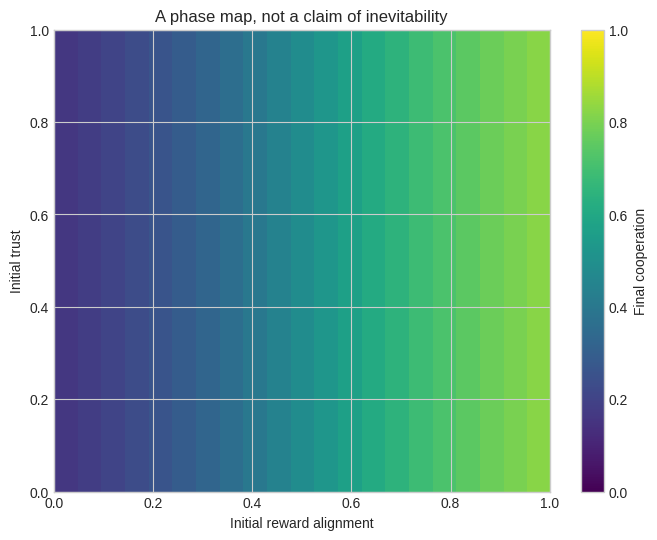

In [3]:
grid = []
for trust in np.linspace(0, 1, 21):
    for alignment in np.linspace(0, 1, 21):
        ic = InitialCondition(trust, alignment, communication_cost=.22, connectivity=.65, exploration=.08)
        final, outcome, _ = simulate_seed(ic, seed=SEED)
        grid.append((trust, alignment, final, outcome))
phase = pd.DataFrame(grid, columns=["trust", "alignment", "final_cooperation", "outcome"])
pivot = phase.pivot(index="trust", columns="alignment", values="final_cooperation")
plt.figure(figsize=(8, 6))
plt.imshow(pivot.values, origin="lower", aspect="auto", extent=[0,1,0,1], cmap="viridis", vmin=0, vmax=1)
plt.colorbar(label="Final cooperation")
plt.xlabel("Initial reward alignment"); plt.ylabel("Initial trust")
plt.title("A phase map, not a claim of inevitability")
plt.show()

## Boundary sensitivity

We identify seeds near the classification threshold and perturb trust slightly. Discontinuous classification around a smooth state variable should not be confused with discontinuous underlying dynamics.

In [6]:
boundary = phase.iloc[(phase.final_cooperation - .67).abs().argsort()[:8]].copy()
tests = []
for _, row in boundary.iterrows():
    for delta in [-.03, 0, .03]:
        ic = InitialCondition(float(np.clip(row.trust+delta,0,1)), row.alignment, .22, .65, .08)
        final, outcome, _ = simulate_seed(ic)
        tests.append({"base_trust": row.trust, "delta": delta, "alignment": row.alignment, "final": final, "outcome": outcome})
pd.DataFrame(tests).round(3)

,base_trust,delta,alignment,final,outcome
0,0.00,-0.03,0.75,0.684,collaboration
1,0.00,0.00,0.75,0.684,collaboration
2,0.00,0.03,0.75,0.684,collaboration
3,0.05,-0.03,0.75,0.684,collaboration
4,0.05,0.00,0.75,0.684,collaboration
5,0.05,0.03,0.75,0.684,collaboration
6,0.10,-0.03,0.75,0.684,collaboration
7,0.10,0.00,0.75,0.684,collaboration
8,0.10,0.03,0.75,0.684,collaboration
9,0.15,-0.03,0.75,0.684,collaboration


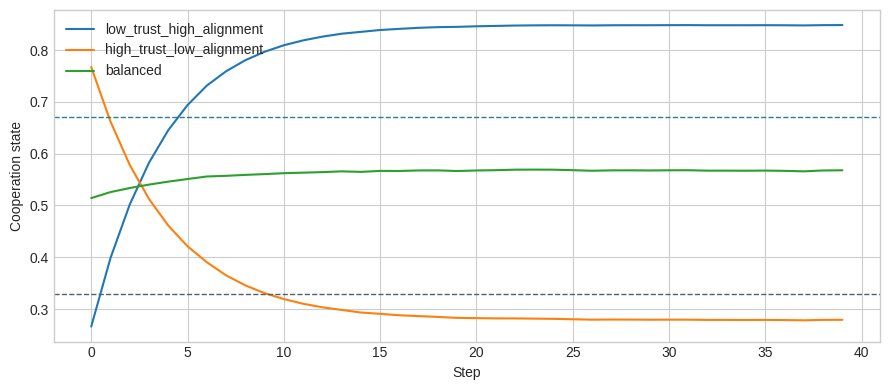

In [8]:
scenarios = {
    "low_trust_high_alignment": InitialCondition(.10,.90,.15,.80,.05),
    "high_trust_low_alignment": InitialCondition(.90,.20,.20,.70,.05),
    "balanced": InitialCondition(.50,.60,.20,.60,.08),
}
plt.figure(figsize=(9,4))
for name, ic in scenarios.items():
    _, _, h = simulate_seed(ic)
    plt.plot(h, label=name)
plt.axhline(.67, color="#2A7F8E", ls="--", lw=1)
plt.axhline(.33, color="#52606D", ls="--", lw=1)
plt.xlabel("Step"); plt.ylabel("Cooperation state"); plt.legend(); plt.tight_layout(); plt.show()

The above cell visualizes the **dynamic trajectories of cooperation over time** for three distinct scenarios. This helps us understand how the 'cooperation' state evolves under different initial settings.

Here's a breakdown of what happens in that cell and what the graph shows:

1.  **Defining Scenarios**: First, three `InitialCondition` instances are created, each representing a unique set of starting parameters:
    *   **`low_trust_high_alignment`**: Characterized by low initial trust but high reward alignment, suggesting agents might eventually cooperate due to shared goals despite initial skepticism.
    *   **`high_trust_low_alignment`**: Starts with high trust but low reward alignment, meaning agents begin cooperatively but might diverge due to conflicting individual incentives.
    *   **`balanced`**: Represents a more moderate initial state, with balanced trust and alignment.

2.  **Simulation and History Collection**: For each of these scenarios, the `simulate_seed` function is called. Instead of just returning the final outcome, this time it also returns `h`, which is the `history` of the cooperation state at each `step` of the simulation.

3.  **Plotting the Trajectories**: These `history` lists are then plotted on a single graph. The x-axis represents the `Step` (time), and the y-axis represents the `Cooperation state` (a value between 0 and 1).

4.  **Threshold Lines**: Two horizontal dashed lines are added to the plot:
    *   **Green dashed line at `0.67`**: This represents the threshold above which the system is classified as 'collaboration'.
    *   **Grey dashed line at `0.33`**: This represents the threshold below which the system is classified as 'fragmentation'. States between these lines are considered 'mixed'.

**Interpreting the Graph**:

*   Each colored line shows how the level of cooperation changes over time for a given scenario. You can observe whether cooperation increases, decreases, or stabilizes.
*   By looking at where each line ends relative to the threshold lines, you can see the final outcome (collaboration, fragmentation, or mixed) for that specific set of initial conditions.
*   For instance, the 'low_trust_high_alignment' scenario (blue line) shows cooperation starting low but eventually rising and stabilizing above the 0.67 threshold, indicating it leads to collaboration. The 'high_trust_low_alignment' (orange line) starts high but drops significantly, while 'balanced' (green line) shows a different trajectory. This visualization helps in understanding the dynamic path the system takes to reach its final state.

## Strongest permissible conclusion

Under the specified transition rule, collaboration occupies structured regions of parameter space and can be sensitive near boundaries. This establishes a topology for the synthetic model, not for LLM cooperation generally.

## Evidentiary boundary

Interpret every numerical result as conditional on the stated rules, parameters, seed, and model class. A result may illustrate a mechanism or reject a null hypothesis inside this synthetic environment. It does not establish intention, consciousness, deception, alignment, or universal LLM behavior.

## Conclusion: The Structured Influence of Initial Conditions on Cooperation

This exploration into parameterized seeding within our synthetic system has illuminated a critical insight: **initial conditions profoundly matter** in determining the long-term emergent behavior of collaboration. Far from being mere arbitrary starting points, these conditions act as crucial determinants, shaping the trajectory and ultimate state of the system. Our 'phase map' clearly demonstrates that collaboration does not emerge indiscriminately; instead, it is confined to specific, identifiable regions within the parameter space. This strongly suggests that the transition between collaborative and non-collaborative states is not a matter of random chance but rather a consequence of the underlying **topology** of the system's dynamics.

It is important to qualify that when we refer to 'initial conditions,' we are not solely implying the instantaneous state of individual agents at `t=0`. Rather, these 'initial conditions' are better understood as encompassing broader **environmental or structural conditions** that define the system's context. Parameters such as `trust`, `reward alignment`, `communication cost`, and `network connectivity` are not ephemeral initial values; they represent the foundational architecture and operating environment of the system. Whether agents begin with a high propensity to trust (a structural condition), or whether the incentive structure consistently rewards aligned actions (an environmental condition), these factors establish the predispositions and constraints within which cooperation either flourishes or falters.

Crucially, the observations made in this notebook distinguish this work from the chaotic unpredictability often associated with complex systems. This is **not a demonstration of chaos theory**, where infinitesimally small changes in initial conditions lead to wildly divergent outcomes. Instead, our findings point to the existence of **structured phase spaces** where similar initial conditions lead to similar outcomes, and shifts in outcome are typically associated with discernible boundaries in the parameter landscape. The 'boundary sensitivity' analysis further supports this by showing that, for certain regions, small perturbations do not necessarily derail the system from its established trajectory, indicating a degree of robustness within the phases.

Ultimately, the purpose of this synthetic experiment is to **figure out *why* cooperation might arise in dynamic settings**—at least within the confines of our carefully constructed model. By systematically varying fundamental parameters and observing their impact on emergent collaboration, we gain a mechanistic understanding of the conditions that favor or hinder collective behavior. While these conclusions are, by design, limited to our synthetic environment and its specific rules, they provide a valuable framework for hypothesizing about the analogous environmental and structural conditions that could foster cooperation in more complex, real-world dynamic systems. This methodological approach allows us to explore the *mechanism* of cooperation, identifying the topological features that govern its emergence, without making unfalsifiable claims about real-world phenomena.